# RobustMesher: 3D Marmousi binary-model meshing

This example uses the bundled Marmousi cube `RobustMesher/velocity_models/marmousi_3d_water.bin` and the original Spyro meshing functions. Run the cells in order: set the inputs, validate the binary layout, build the sizing function, generate and export the mesh, and plot it.

From the repository folder, install with `python -m pip install -e .` and open this notebook. The model is loaded as package data, so it is also available after a normal pip installation. Coordinates and element sizes use metres, velocity uses m/s, and frequency uses Hz.

The supplied cube has **`(nz, nx, ny) = (876, 2301, 17)`**, with spacings **`(dz, dx, dy) = (4, 4, 250)` m**, and covers **9200 m × 4000 m × 3500 m** in `(x, y, depth)`. It extrudes Marmousi through 4 km in y and adds a **500 m water column** above the original 2D model. Water is **1500 m/s**; velocities range from 1500 to 5500 m/s. The file stores **big-endian float32 values in Fortran order**, with canonical axes `(z, x, y)`.

The configured example uses a **1 Hz** sizing frequency, **50 m** initial structured hexahedra, a delimited water interface, and **500 Numba Winslow iterations** with relaxation 0.10 and no padding. Native Savitzky-Golay grading smooths the sizing cube in z, x, then y. Its retained output records **1,113,396 exported nodes** and **1,078,920 hexahedra**.

The execution outputs and figures supplied with this notebook are retained from the user's run. This staged notebook was validated for format and Python syntax without repeating its large mesh calculation.

In [1]:
from importlib.resources import files
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from RobustMesher import generate_mesh, plot_mesh
from RobustMesher.Io_utils import _read_velocity_binary3D
from RobustMesher.sizing_utils import create_sizing_function3D

## Inputs

Every configurable input is annotated on its right. Set the physical extent to match the supplied velocity model.

In [2]:
velocity_file = Path(str(files("RobustMesher").joinpath("velocity_models", "marmousi_3d_water.bin")))  # Packaged Marmousi binary cube.
output_dir = Path("output")                               # Directory for exported mesh and figures.
mesh_file = output_dir / "marmousi_mesh_3D.msh"             # Gmsh mesh output, including physical groups.
figure_file = output_dir / "marmousi_mesh_3D.png"           # Mesh preview image output.

nz = 876                      # Number of depth samples: 500 m added water plus the original Marmousi depth.
nx = 2301                      # Number of x samples across the 9200 m Marmousi width.
ny = 17                      # Number of extrusion samples across the 4000 m y width.
dz = 4.0                      # Depth spacing in metres.
dx = 4.0                      # Horizontal x spacing in metres.
dy = 250.0                     # Horizontal y spacing in metres.
length_x = (nx - 1) * dx      # Physical model width in x, in metres.
length_y = (ny - 1) * dy      # Physical model width in y, in metres.
length_z = (nz - 1) * dz      # Positive physical model depth, in metres.
byte_order = "big"            # Binary endianness: "big" or "little".
axes_order = (0, 1, 2)        # Binary-axis permutation into the source's (z, x, y) convention.
axes_order_sort = "F"          # Binary reshape memory order: "F" for the supplied cube, or "C".
binary_dtype = "float32"       # Numeric scalar type stored in the binary file.

frequency = 1.0               # Frequency in Hz used to convert velocity to wavelength.
cells_per_wavelength = 2.0    # Elements per wavelength in the velocity-derived sizing field.
hmin_segy = 0.0               # Minimum sizing-field value; 0 keeps the wavelength-derived values.
grade = 0.05                  # Native Savitzky-Golay smoothing in z, then x, then y.
vp_water = 1500.0             # Fallback velocity for zeros; actual Marmousi water is 1500 m/s.

padding_type = None           # None, "rectangular", or "hyperelliptical" padding geometry.
padding_x = 1000.0            # Left/right x padding thickness in metres.
padding_y = 1000.0            # Front/back y padding thickness in metres.
padding_z = 1000.0            # Bottom padding thickness in metres; the upper boundary stays free.
hyper_n = 4.0                 # Hyperellipsoid exponent; used for hyperelliptical padding.
extend_segy = True            # Extend model-derived sizes into padding; False blends toward h_padding.
h_padding = 1000.0            # Outer padding element size in metres when extend_segy is False.
water_interface = True        # Split water/subsoil volumes using the velocity-model interface.
water_search_value = 1500.0   # Actual Marmousi water marker in m/s; it is not zero.
added_water_depth = 500.0     # Known added uniform water column in metres; use None for another model.

structured_mesh = True        # True creates structured hexahedra; False creates unstructured tetrahedra.
min_element_size = 50.0      # Initial structured-mesh element size in metres; smaller creates more cells.
apply_winslow = True          # Apply source 3D Winslow adaptation to a structured supported geometry.
winslow_implementation = "numba" # The original 3D implementation supports "numba" only.
winslow_iterations = 500        # Configured Winslow iteration count.
winslow_omega = 0.10          # Winslow relaxation factor; smaller values move nodes more cautiously.
gmsh_parallel = False         # True uses the source point-cloud field and parallel HXT meshing setup.
gmsh_num_threads = 1          # Number of Gmsh/HXT threads when gmsh_parallel is True.

if not velocity_file.is_file():
    raise FileNotFoundError(f"Velocity model not found: {velocity_file.resolve()}")
expected_bytes = nz * nx * ny * np.dtype(binary_dtype).itemsize
actual_bytes = velocity_file.stat().st_size
if actual_bytes != expected_bytes:
    raise ValueError(
        f"Binary layout mismatch: {velocity_file.name} contains {actual_bytes:,} bytes; "
        f"shape {(nz, nx, ny)} and dtype {binary_dtype} require {expected_bytes:,} bytes."
    )
print(f"Binary file: {velocity_file}")
print(f"Shape (z, x, y): {(nz, nx, ny)}; spacings: {(dz, dx, dy)} m")
print(f"Extent (x, y, depth): {(length_x, length_y, length_z)} m")
print(f"Storage: {byte_order}-endian {binary_dtype}, {axes_order_sort} order, axes {axes_order}")
print(f"Binary size verified: {actual_bytes:,} bytes")
output_dir.mkdir(parents=True, exist_ok=True)

Binary file: /home/juninhoras/firedrakes/spyro/RobustMesher/velocity_models/marmousi_3d_water.bin
Shape (z, x, y): (876, 2301, 17); spacings: (4.0, 4.0, 250.0) m
Extent (x, y, depth): (9200.0, 4000.0, 3500.0) m
Storage: big-endian float32, F order, axes (0, 1, 2)
Binary size verified: 137,065,968 bytes


## Create the sizing function

This explicitly constructs the sizing field before calling mesh generation. The original returned tuple carries the callable and model dimensions into the standalone generator.

In [3]:
sizing_result = create_sizing_function3D(
    fname=str(velocity_file),
    hmin=hmin_segy,
    bbox=(-length_z, 0.0, 0.0, length_x, 0.0, length_y),
    wl=cells_per_wavelength,
    freq=frequency,
    pad_type=padding_type,
    pad_size_x=padding_x,
    pad_size_y=padding_y,
    pad_size_z=padding_z,
    grade=grade,
    vp_water=vp_water,
    nz=nz,
    nx=nx,
    ny=ny,
    byte_order=byte_order,
    axes_order=axes_order,
    axes_order_sort=axes_order_sort,
    dtype=binary_dtype,
)
sizing_function, hmin, hmax, nz_read, nx_read, ny_read = sizing_result
hmax_label = f"{hmax:.2f}" if hmax is not None else "not available"
print(f"Sizing field built for cube {(nz_read, nx_read, ny_read)}; h minimum = {hmin:.2f} m; maximum = {hmax_label}")

Sizing field built for cube (876, 2301, 17); h minimum = 750.00 m; maximum = 2950.35


Velocity range: 1500.0 to 5500.0 m/s
Water samples at 1500 m/s: 5,205,264
Added water column verified: first 125 depth samples are 1500 m/s


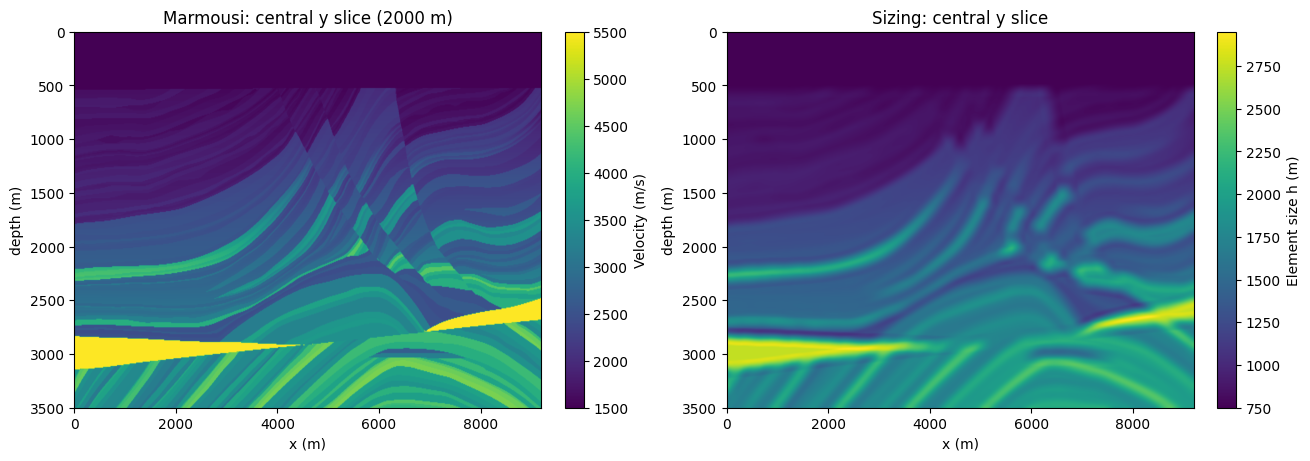

In [4]:
velocity = _read_velocity_binary3D(
    fname=str(velocity_file), nz=nz, nx=nx, ny=ny,
    byte_order=byte_order, axes_order=axes_order,
    axes_order_sort=axes_order_sort, dtype=binary_dtype,
)
if velocity.shape != (nz, nx, ny):
    raise ValueError(f"Read shape {velocity.shape} does not match configured shape {(nz, nx, ny)}.")
if not np.all(np.isfinite(velocity)) or np.any(velocity <= 0.0):
    raise ValueError("Binary velocity data must contain finite positive values; check the layout inputs.")
print(f"Velocity range: {velocity.min():.1f} to {velocity.max():.1f} m/s")
print(f"Water samples at {water_search_value:g} m/s: {np.count_nonzero(np.isclose(velocity, water_search_value)):,}")
if added_water_depth is not None:
    water_samples = int(round(added_water_depth / dz))
    if not np.all(np.isclose(velocity[:water_samples], water_search_value, atol=1e-3, rtol=0.0)):
        raise ValueError("The known added water column is misplaced; check endianness, reshape order, and axes.")
    print(f"Added water column verified: first {water_samples} depth samples are {water_search_value:g} m/s")
iy = ny // 2
x_plot = np.linspace(0.0, length_x, nx)
depth_plot = np.linspace(0.0, length_z, nz)
xx, dd = np.meshgrid(x_plot, depth_plot)
coordinates = np.column_stack((-dd.ravel(), xx.ravel(), np.full(xx.size, iy * dy)))
size_plot = sizing_function(coordinates).reshape(nz, nx)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for ax, values, title, label in zip(
    axes, [velocity[:, :, iy], size_plot],
    [f"Marmousi: central y slice ({iy * dy:g} m)", "Sizing: central y slice"],
    ["Velocity (m/s)", "Element size h (m)"],
):
    image = ax.imshow(values, extent=(0, length_x, length_z, 0), aspect="auto")
    ax.set(xlabel="x (m)", ylabel="depth (m)", title=title)
    fig.colorbar(image, ax=ax, label=label)
plt.show()

## Generate and export the mesh

The generator receives the previously created sizing function and the geometry/adaptation parameters. It writes the Gmsh `.msh` file with the original physical groups and returns a mesh for plotting.

In [5]:
mesh = generate_mesh(
    sizing_function=sizing_result,
    dimension=3,
    velocity_file=str(velocity_file),
    length_x=length_x,
    length_y=length_y,
    length_z=length_z,
    padding_type=padding_type,
    padding_x=padding_x,
    padding_y=padding_y,
    padding_z=padding_z,
    hyper_n=hyper_n,
    extend_segy=extend_segy,
    h_padding=h_padding,
    water_interface=water_interface,
    water_search_value=water_search_value,
    vp_water=vp_water,
    structured_mesh=structured_mesh,
    min_element_size=min_element_size,
    apply_winslow=apply_winslow,
    winslow_implementation=winslow_implementation,
    winslow_iterations=winslow_iterations,
    winslow_omega=winslow_omega,
    segy_nz=nz,
    segy_nx=nx,
    segy_ny=ny,
    segy_dz=dz,
    segy_dx=dx,
    segy_dy=dy,
    segy_byte_order=byte_order,
    segy_axes_order=axes_order,
    segy_axes_order_sort=axes_order_sort,
    segy_dtype=binary_dtype,
    gmsh_parallel=gmsh_parallel,
    gmsh_num_threads=gmsh_num_threads,
    output_filename=str(mesh_file),
)
print(f"Mesh exported: {mesh_file.resolve()}")
print(f"Nodes: {len(mesh.points):,}")
for block in mesh.cells:
    if block.type in {"tetra", "hexahedron"}:
        print(f"{block.type}: {len(block.data):,}")

Generating 3D Gmsh mesh...
Info    : Clearing all models and views...
Info    : Done clearing all models and views
Generating geometrically delimited water and subsurface volumes...


/home/juninhoras/firedrakes/spyro/RobustMesher/generation_utils/parameters.py:458: UserWarning: _length_z value (3500.0) appears to be in meters, but the current unit is km. Please check for consistency.
  warn(
/home/juninhoras/firedrakes/spyro/RobustMesher/generation_utils/parameters.py:458: UserWarning: _length_x value (9200.0) appears to be in meters, but the current unit is km. Please check for consistency.
  warn(
/home/juninhoras/firedrakes/spyro/RobustMesher/generation_utils/parameters.py:458: UserWarning: _length_y value (4000.0) appears to be in meters, but the current unit is km. Please check for consistency.
  warn(
/home/juninhoras/firedrakes/spyro/RobustMesher/generation_utils/parameters.py:458: UserWarning: _padding_x value (1000.0) appears to be in meters, but the current unit is km. Please check for consistency.
  warn(
/home/juninhoras/firedrakes/spyro/RobustMesher/generation_utils/parameters.py:458: UserWarning: _padding_y value (1000.0) appears to be in meters, but 

Info    : Meshing 1D...nts - Splitting faces                                                                                           
Info    : [  0%] Meshing curve 5 (Line)
Info    : [ 10%] Meshing curve 6 (Line)
Info    : [ 10%] Meshing curve 7 (Line)
Info    : [ 20%] Meshing curve 8 (Line)
Info    : [ 20%] Meshing curve 21 (Line)
Info    : [ 30%] Meshing curve 22 (Line)
Info    : [ 30%] Meshing curve 23 (Line)
Info    : [ 30%] Meshing curve 24 (Line)
Info    : [ 40%] Meshing curve 25 (Line)
Info    : [ 40%] Meshing curve 26 (Line)
Info    : [ 50%] Meshing curve 27 (Line)
Info    : [ 50%] Meshing curve 28 (Line)
Info    : [ 60%] Meshing curve 29 (BSpline)
Info    : [ 60%] Meshing curve 30 (BSpline)
Info    : [ 60%] Meshing curve 31 (BSpline)
Info    : [ 70%] Meshing curve 32 (BSpline)
Info    : [ 70%] Meshing curve 33 (Line)
Info    : [ 80%] Meshing curve 34 (Line)
Info    : [ 80%] Meshing curve 35 (Line)
Info    : [ 80%] Meshing curve 36 (Line)
Info    : [ 90%] Meshing curve 37 (L

## Plot the exported mesh

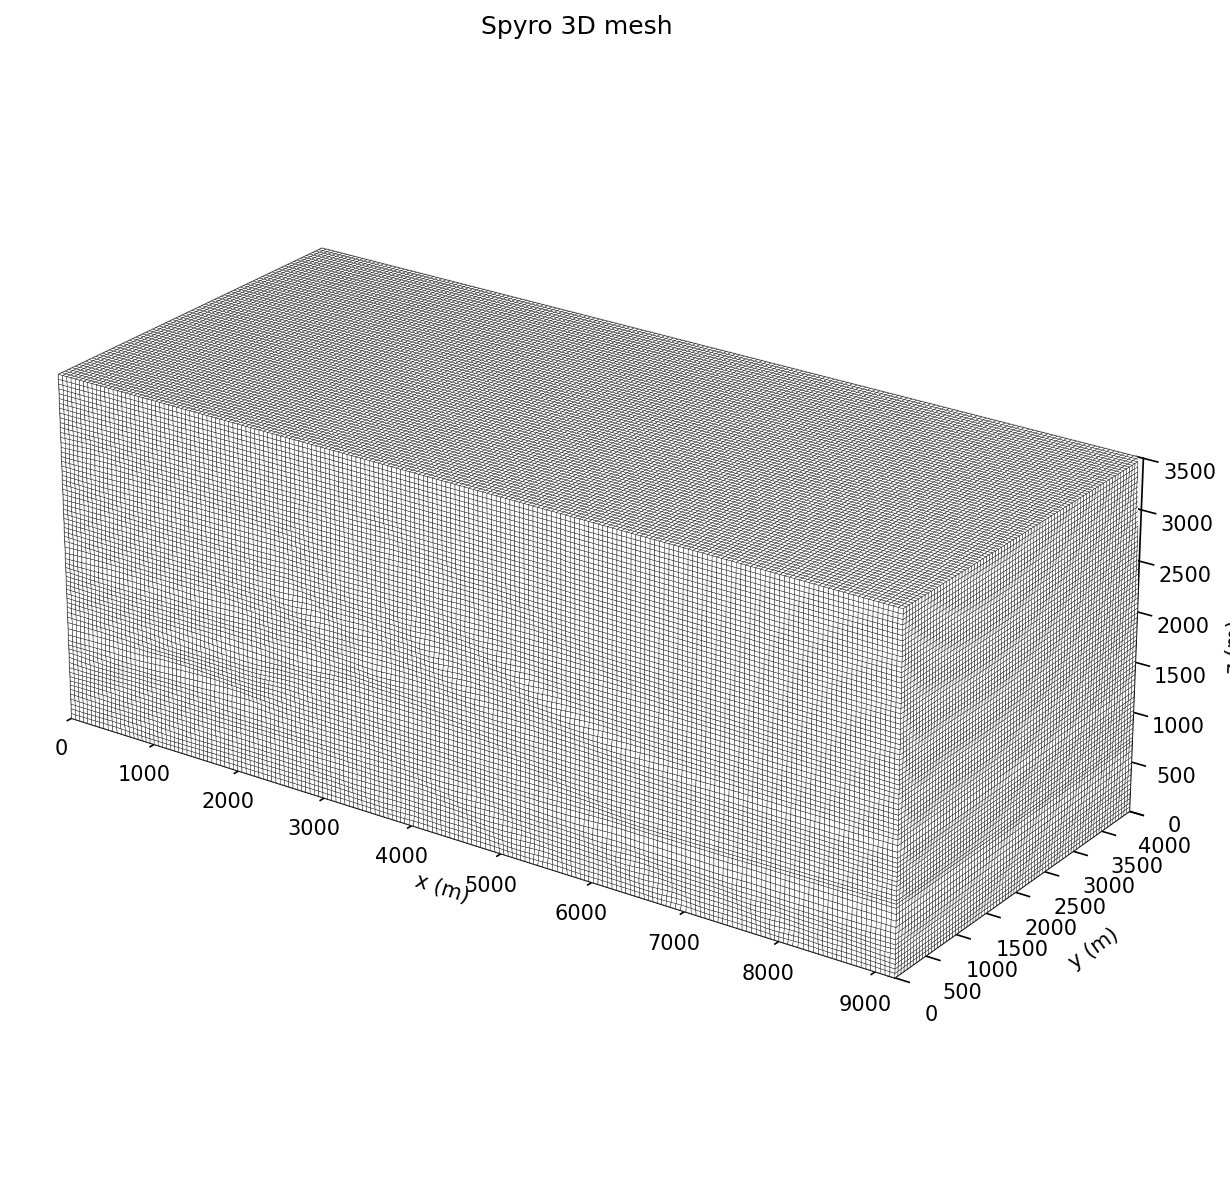

<Figure size 640x480 with 0 Axes>

Mesh preview saved: /home/juninhoras/firedrakes/spyro/output/marmousi_mesh_3D.png


In [6]:
plot_mesh(mesh, dimension=3)
plt.gcf().savefig(figure_file, dpi=180, bbox_inches="tight")
plt.show()
print(f"Mesh preview saved: {figure_file.resolve()}")